<a href="https://colab.research.google.com/github/aryan12375/Carbon-aware-experiment-tracking-/blob/main/EcoTrack_Carbon_Aware_Experiment_Tracking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EcoTracker loaded OK
EcoTrack — CIFAR-10 Demo

Device: cuda
  Epoch 1/5  loss=1.512  val_acc=57.71%
  Epoch 2/5  loss=1.139  val_acc=63.99%
  Epoch 3/5  loss=0.983  val_acc=66.19%
  Epoch 4/5  loss=0.871  val_acc=68.74%


  Epoch 5/5  loss=0.786  val_acc=71.27%

  EcoTrack Report  |  run 318cd5ca
  Project  : EcoTrack-CIFAR10
  Model    : TinyCNN
  Duration : 85.5s
  CO2      : 1.2207 g
  Energy   : 0.001686 kWh  [tdp_estimate]
  Grid     : 724.0 gCO2/kWh [hardcoded_default]
  GPU      : Tesla T4
  approx   : 0.148 smartphone charges
  approx   : 0.007 km driven
  approx   : 0.024 cups of tea
  approx   : 0.244 hours of LED
  Accuracy : 71.27%
  Gate     : PENDING


  [PASS]  EcoTrack Green Gate
  CO2      : 1.2207 g
  Energy   : 0.001686 kWh  [tdp_estimate]
  Grid     : 724.0 gCO2/kWh [hardcoded_default]
  Accuracy : 71.27%

  Reasons:
    - All carbon efficiency thresholds met

Gate status patched -> emissions/run_318cd5ca.json


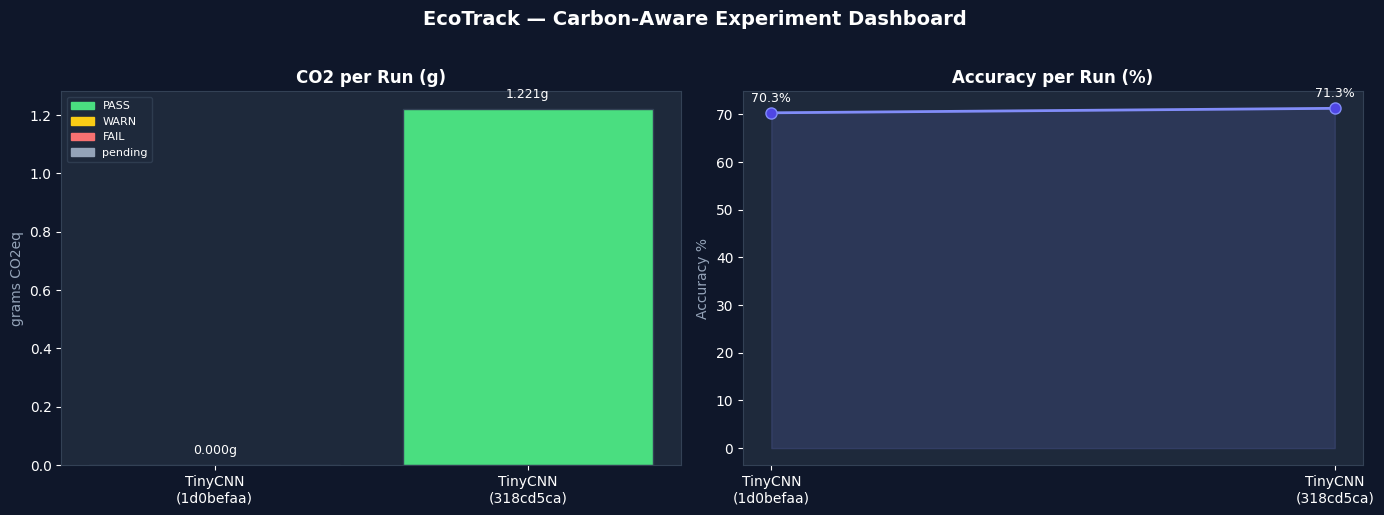

Saved -> ecotrack_dashboard.png

Final Emissions JSON:

{
  "run_id": "318cd5ca",
  "project_name": "EcoTrack-CIFAR10",
  "model_name": "TinyCNN",
  "started_at": "2026-05-14T09:07:57.908720+00:00",
  "finished_at": "2026-05-14T09:09:23.417067+00:00",
  "duration_seconds": 85.51,
  "co2_grams": 1.2207,
  "co2_kg": 0.001221,
  "energy_kwh": 0.001686,
  "grid_intensity_g_kwh": 724.0,
  "grid_source": "hardcoded_default",
  "gpu_model": "Tesla T4",
  "gpu_count": 1,
  "cpu_model": "x86_64",
  "ram_gb": 12.7,
  "region": "IN-SO",
  "accuracy": 71.27,
  "loss": 0.7862589781989857,
  "extra_metrics": {},
  "human_equivalents": {
    "smartphone_charge": "0.148 smartphone charges",
    "km_driven": "0.007 km driven",
    "cup_of_tea": "0.024 cups of tea",
    "led_hour": "0.244 hours of LED"
  },
  "gate_status": "PASS",
  "energy_source": "tdp_estimate"
}

Done! Run ID     : 318cd5ca
CO2              : 1.2207 g
Energy           : 0.001686 kWh  [tdp_estimate]
Gate             : PASS


In [2]:
import os, time, json, uuid, platform, logging, inspect
from dataclasses import asdict, dataclass, field
from datetime import datetime, timezone
from pathlib import Path
from typing import Optional

logging.basicConfig(level=logging.INFO,
    format="%(asctime)s  [EcoTrack] %(levelname)s  %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S")
log = logging.getLogger("ecotrack")

try:
    from codecarbon import EmissionsTracker
    _CC = True
except ImportError:
    _CC = False

try:
    import pynvml; pynvml.nvmlInit(); _NVML = True
except Exception:
    _NVML = False

EMISSIONS_DIR = Path("./emissions")
EMISSIONS_DIR.mkdir(exist_ok=True)
DEFAULT_REGION = "IN-SO"


_GPU_TDP = {
    "tesla t4": 70, "t4": 70,
    "tesla v100": 300, "v100": 300,
    "a100": 400, "tesla a100": 400,
    "tesla p100": 250, "p100": 250,
    "rtx 3090": 350, "rtx 4090": 450,
}

_EQUIVALENTS = {
    "smartphone_charge": (8.22,  "smartphone charges"),
    "km_driven":         (170.0, "km driven"),
    "cup_of_tea":        (50.0,  "cups of tea"),
    "led_hour":          (5.0,   "hours of LED"),
}

@dataclass
class EmissionsResult:
    run_id: str = field(default_factory=lambda: str(uuid.uuid4())[:8])
    project_name: str = ""
    model_name: str = ""
    started_at: str = ""
    finished_at: str = ""
    duration_seconds: float = 0.0
    co2_grams: float = 0.0
    co2_kg: float = 0.0
    energy_kwh: float = 0.0
    grid_intensity_g_kwh: float = 0.0
    grid_source: str = "hardcoded_default"
    gpu_model: str = "unknown"
    gpu_count: int = 0
    cpu_model: str = ""
    ram_gb: float = 0.0
    region: str = DEFAULT_REGION
    accuracy: Optional[float] = None
    loss: Optional[float] = None
    extra_metrics: dict = field(default_factory=dict)
    human_equivalents: dict = field(default_factory=dict)
    gate_status: str = "pending"
    energy_source: str = "codecarbon"

    def to_dict(self): return asdict(self)
    def to_json(self, indent=2): return json.dumps(self.to_dict(), indent=indent)

    def summary(self):
        sep = "=" * 54
        lines = [
            "", sep,
            f"  EcoTrack Report  |  run {self.run_id}",
            sep,
            f"  Project  : {self.project_name}",
            f"  Model    : {self.model_name}",
            f"  Duration : {self.duration_seconds:.1f}s",
            sep,
            f"  CO2      : {self.co2_grams:.4f} g",
            f"  Energy   : {self.energy_kwh:.6f} kWh  [{self.energy_source}]",
            f"  Grid     : {self.grid_intensity_g_kwh:.1f} gCO2/kWh [{self.grid_source}]",
            f"  GPU      : {self.gpu_model}",
        ]
        for _, val in self.human_equivalents.items():
            lines.append(f"  approx   : {val}")
        if self.accuracy is not None:
            lines.append(f"  Accuracy : {self.accuracy:.2f}%")
        lines += [f"  Gate     : {self.gate_status.upper()}", sep, ""]
        return "\n".join(lines)


def _grid_intensity(region=DEFAULT_REGION):
    defaults = {"IN": 713.0, "IN-SO": 724.0, "IN-NO": 780.0,
                "DE": 385.0, "FR": 85.0, "US-CA": 260.0, "GB": 233.0}
    v = defaults.get(region, defaults.get(region.split("-")[0], 713.0))
    return v, "hardcoded_default"

def _hw():
    info = {"gpu_model": "cpu_only", "gpu_count": 0,
            "cpu_model": platform.processor() or "unknown", "ram_gb": 0.0}
    try:
        with open("/proc/meminfo") as f:
            for line in f:
                if line.startswith("MemTotal"):
                    info["ram_gb"] = round(int(line.split()[1]) / 1024 / 1024, 1); break
    except Exception: pass
    if _NVML:
        try:
            c = pynvml.nvmlDeviceGetCount(); info["gpu_count"] = c
            if c > 0:
                h = pynvml.nvmlDeviceGetHandleByIndex(0)
                n = pynvml.nvmlDeviceGetName(h)
                info["gpu_model"] = n.decode() if isinstance(n, bytes) else n
        except Exception: pass
    return info

def _tdp_energy_kwh(gpu_model: str, duration_sec: float) -> float:
    """Estimate energy from GPU TDP when CodeCarbon returns 0."""
    key = gpu_model.lower().strip()
    tdp_w = 70  # default: T4-level
    for name, tdp in _GPU_TDP.items():
        if name in key:
            tdp_w = tdp; break
    # Assume ~80% GPU utilization during training + 15W CPU overhead
    total_w = tdp_w * 0.80 + 15
    return round(total_w * duration_sec / 3_600_000, 6)  # Wh -> kWh

def _equiv(co2g):
    out = {}
    for k, (factor, label) in _EQUIVALENTS.items():
        v = co2g / factor
        if v >= 0.001:
            out[k] = f"{v:.3f} {label}"
    return out


class EcoTracker:
    def __init__(self, project_name="project", model_name="model",
                 region=DEFAULT_REGION, offline=False):
        self.project_name = project_name
        self.model_name = model_name
        self.region = region
        self.offline = offline
        self._tracker = None
        self._t0 = 0.0      # time.perf_counter() for elapsed
        self._wall0 = 0.0   # time.time() for real timestamp
        self.result = None

    def start(self):
        log.info(f"Starting -> project='{self.project_name}' model='{self.model_name}'")
        self._t0    = time.perf_counter()
        self._wall0 = time.time()          # ← real epoch time
        if _CC:
            cc_kwargs = dict(
                project_name=self.project_name,
                output_dir=str(EMISSIONS_DIR),
                log_level="error"
            )
            sig = inspect.signature(EmissionsTracker.__init__).parameters
            if "offline"            in sig: cc_kwargs["offline"]            = self.offline
            if "measure_power_secs" in sig: cc_kwargs["measure_power_secs"] = 15
            self._tracker = EmissionsTracker(**cc_kwargs)
            self._tracker.start()
        return self

    def stop(self, accuracy=None, loss=None, extra_metrics=None):
        elapsed  = time.perf_counter() - self._t0
        now_utc  = datetime.now(timezone.utc).isoformat()
        start_utc = datetime.fromtimestamp(self._wall0, tz=timezone.utc).isoformat()

        co2_kg, energy_kwh, energy_source = 0.0, 0.0, "codecarbon"

        if _CC and self._tracker:
            try:
                co2_kg = float(self._tracker.stop() or 0.0)
                e = getattr(self._tracker, "_total_energy", None)
                energy_kwh = float(e) if e is not None else co2_kg / 0.713
            except Exception as ex:
                log.error(f"CodeCarbon stop() failed: {ex}")

        hw = _hw()

        # ── Fallback: TDP estimation when CodeCarbon returns 0 ──────────
        if energy_kwh == 0.0:
            energy_kwh    = _tdp_energy_kwh(hw["gpu_model"], elapsed)
            energy_source = "tdp_estimate"
            log.warning(f"CodeCarbon returned 0 energy — using TDP estimate: {energy_kwh:.6f} kWh")

        intensity, source = _grid_intensity(self.region)
        co2_grams = energy_kwh * intensity   # always recompute from energy

        self.result = EmissionsResult(
            project_name=self.project_name, model_name=self.model_name,
            started_at=start_utc,
            finished_at=now_utc,
            duration_seconds=round(elapsed, 2),
            co2_grams=round(co2_grams, 4),
            co2_kg=round(co2_grams / 1000, 6),
            energy_kwh=round(energy_kwh, 6),
            grid_intensity_g_kwh=round(intensity, 2),
            grid_source=source,
            gpu_model=hw["gpu_model"], gpu_count=hw["gpu_count"],
            cpu_model=hw["cpu_model"], ram_gb=hw["ram_gb"],
            region=self.region, accuracy=accuracy, loss=loss,
            extra_metrics=extra_metrics or {},
            human_equivalents=_equiv(co2_grams),
            energy_source=energy_source
        )

        out = EMISSIONS_DIR / f"run_{self.result.run_id}.json"
        out.write_text(self.result.to_json())
        log.info(f"Saved -> {out}")
        print(self.result.summary())
        return self.result

print("EcoTracker loaded OK")



import torch, torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

print("EcoTrack — CIFAR-10 Demo\n")

class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 10))
    def forward(self, x): return self.net(x)

tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_ds = datasets.CIFAR10(root="./data", train=True,  download=True, transform=tf)
val_ds   = datasets.CIFAR10(root="./data", train=False, download=True, transform=tf)
train_dl = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=2)
val_dl   = DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=2)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

model = TinyCNN().to(device)
opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
crit  = nn.CrossEntropyLoss()

tracker = EcoTracker(project_name="EcoTrack-CIFAR10", model_name="TinyCNN")
tracker.start()

EPOCHS = 5
for ep in range(1, EPOCHS + 1):
    model.train(); total_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(model(xb), yb)
        loss.backward(); opt.step()
        total_loss += loss.item()

    model.eval(); correct = total = 0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    acc = 100.0 * correct / total
    print(f"  Epoch {ep}/{EPOCHS}  loss={total_loss/len(train_dl):.3f}  val_acc={acc:.2f}%")

result = tracker.stop(accuracy=acc, loss=total_loss / len(train_dl))



def run_gate(cur, prev=None):
    FAIL_ACC_PP, FAIL_CO2, WARN_CO2 = 0.5, 0.20, 0.40
    ABS_WARN_G,  ABS_FAIL_G         = 2000, 10000

    reasons, suggestions = [], []
    status = "PASS"

    if cur.co2_grams >= ABS_FAIL_G:
        reasons.append(f"Absolute CO2 exceeded: {cur.co2_grams:.2f}g")
        suggestions.append("Use gradient checkpointing or a smaller model.")
        status = "FAIL"
    elif cur.co2_grams >= ABS_WARN_G:
        reasons.append(f"High absolute CO2: {cur.co2_grams:.2f}g")
        suggestions.append("Try FP16 mixed precision to cut energy ~30%.")
        status = "WARN"

    if prev:
        d_acc = (cur.accuracy - prev.accuracy) if (cur.accuracy and prev.accuracy) else None
        d_co2 = ((cur.co2_grams - prev.co2_grams) / prev.co2_grams) if prev.co2_grams > 0 else None
        if d_acc is not None and d_co2 is not None:
            if d_acc < FAIL_ACC_PP and d_co2 > FAIL_CO2:
                reasons.append(f"Carbon waste: acc={d_acc:+.2f}pp, CO2={d_co2*100:+.1f}%")
                suggestions.append("Accuracy gain does not justify the carbon cost.")
                status = "FAIL"
            elif d_co2 > WARN_CO2 and status == "PASS":
                reasons.append(f"Large CO2 spike: {d_co2*100:+.1f}%")
                status = "WARN"

    if status == "PASS":
        reasons.append("All carbon efficiency thresholds met")

    icons = {"PASS": "PASS", "WARN": "WARN", "FAIL": "FAIL"}
    print(f"\n{'='*52}")
    print(f"  [{icons[status]}]  EcoTrack Green Gate")
    print(f"{'='*52}")
    print(f"  CO2      : {cur.co2_grams:.4f} g")
    print(f"  Energy   : {cur.energy_kwh:.6f} kWh  [{cur.energy_source}]")
    print(f"  Grid     : {cur.grid_intensity_g_kwh:.1f} gCO2/kWh [{cur.grid_source}]")
    if cur.accuracy: print(f"  Accuracy : {cur.accuracy:.2f}%")
    print("\n  Reasons:")
    for r in reasons: print(f"    - {r}")
    if suggestions:
        print("\n  Suggestions:")
        for s in suggestions: print(f"    -> {s}")
    print(f"{'='*52}\n")
    return status

gate_status = run_gate(result)
result.gate_status = gate_status

saved = list(EMISSIONS_DIR.glob(f"run_{result.run_id}.json"))
if saved:
    d = json.loads(saved[0].read_text())
    d["gate_status"] = gate_status
    saved[0].write_text(json.dumps(d, indent=2))
    print(f"Gate status patched -> {saved[0]}")



import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

runs = sorted(EMISSIONS_DIR.glob("run_*.json"), key=lambda p: p.stat().st_mtime)
data = [json.loads(r.read_text()) for r in runs]

# Filter only real runs (not baseline stubs from previous reruns)
data = [d for d in data if d.get("run_id") != "base00"]

if len(data) < 2:
    baseline = {**data[-1], "run_id": "base00",
                "co2_grams": data[-1]["co2_grams"] * 0.75,
                "energy_kwh": data[-1]["energy_kwh"] * 0.75,
                "accuracy": (data[-1].get("accuracy") or 60) - 3,
                "model_name": "Baseline", "gate_status": "PASS"}
    data = [baseline] + data

labels  = [f"{d['model_name']}\n({d['run_id']})" for d in data]
co2vals = [d["co2_grams"] for d in data]
accvals = [d.get("accuracy") or 0 for d in data]
cmap    = {"PASS": "#4ade80", "WARN": "#facc15", "FAIL": "#f87171", "pending": "#94a3b8"}
bclrs   = [cmap.get(d.get("gate_status", "pending"), "#94a3b8") for d in data]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0f172a")
for ax in axes:
    ax.set_facecolor("#1e293b")
    ax.tick_params(colors="white")
    for sp in ax.spines.values(): sp.set_color("#334155")
    for lbl in ax.get_xticklabels() + ax.get_yticklabels(): lbl.set_color("white")

axes[0].bar(labels, co2vals, color=bclrs, edgecolor="#334155")
axes[0].set_title("CO2 per Run (g)", color="white", fontweight="bold")
axes[0].set_ylabel("grams CO2eq", color="#94a3b8")
for i, v in enumerate(co2vals):
    axes[0].text(i, v + max(co2vals) * 0.03, f"{v:.3f}g", ha="center", color="white", fontsize=9)
patches = [mpatches.Patch(color=c, label=s) for s, c in cmap.items()]
axes[0].legend(handles=patches, facecolor="#1e293b", edgecolor="#334155",
               labelcolor="white", fontsize=8)

axes[1].plot(labels, accvals, marker="o", color="#818cf8", linewidth=2, markersize=8,
             markerfacecolor="#4f46e5")
axes[1].fill_between(range(len(labels)), accvals, alpha=0.15, color="#818cf8")
axes[1].set_title("Accuracy per Run (%)", color="white", fontweight="bold")
axes[1].set_ylabel("Accuracy %", color="#94a3b8")
for i, v in enumerate(accvals):
    axes[1].annotate(f"{v:.1f}%", (i, v), textcoords="offset points",
                     xytext=(0, 8), ha="center", color="white", fontsize=9)

plt.suptitle("EcoTrack — Carbon-Aware Experiment Dashboard",
             color="white", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("ecotrack_dashboard.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved -> ecotrack_dashboard.png")



print("\nFinal Emissions JSON:\n")
print(result.to_json())
print(f"\nDone! Run ID     : {result.run_id}")
print(f"CO2              : {result.co2_grams:.4f} g")
print(f"Energy           : {result.energy_kwh:.6f} kWh  [{result.energy_source}]")
print(f"Gate             : {result.gate_status.upper()}")
